# Field Line Tracing Accuracy Verification in Geopack(Scalar vs Vectorized)


This notebook validates the

**tracing accuracy** of `geopack.trace()` (scalar) and `geopack.trace_vectorized()` (vectorized).


---

## Validation perspectives (3 parts)


1. **Scalar vs Vectorized agreement**

   - Endpoint difference (Δx,Δy,Δz,Δr)

   - Full path difference (resample at same normalized arc length, compute RMS)


2. **Geometric consistency (is the path tangent to B?)**

   - Angle error (deg) between path tangent vector t and B

     - θ = arccos(|t·B̂|)


3. **Reversibility (does a round-trip return to the start?)**

   - Trace forward (dir=+1) to reach r0, shift slightly outward, then reverse (dir=-1)

   - Difference from the original starting point


---

## Important

- Always call `geopack.recalc(ut)` before `trace` (updates IGRF coefficients, psi, etc.)

- `trace_vectorized` supports switching `strict_scalar_models=True/False`:

  - True: Evaluate model point-by-point, prioritize consistency (slow)

  - False: Use vectorized model for speedup (may produce small differences)


Evaluation follows the implementation specification (status, stop conditions, ds logic).

## 1) Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from datetime import datetime
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from mageometry import geopack
from mageometry.geopack import recalc

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

print("Environment")
import sys
print("  python:", sys.version.split()[0])
print("  numpy :", np.__version__)


Load IGRF coefficients ...
Environment
  python: 3.11.1
  numpy : 2.2.6


### Notebook-wide knobs

In [2]:
# --- tracing knobs ---
R0   = 1.0
RLIM = 15.0
MAXLOOP = 200

# --- model selection ---
EXNAME = "t96"     # "t89" | "t96" | "t01" | "t04"
INNAME = "igrf"    # "igrf" | "dip"

# --- accuracy test size ---
N_STARTS = 120     # Number of starting points (too many will be slow)

# --- vectorized settings ---
STRICT_SCALAR_MODELS = False   # True=consistency, False=speed

# --- tolerances ---
R0_TOL = 3e-3          # Radius tolerance for considering endpoint reached r0
REVERSE_EPS = 1e-3     # Relative offset from boundary for round-trip test

# --- resampling ---
RESAMPLE_N = 200       # Number of resample points for path comparison

# --- plotting ---
PLOT_EARTH = True


## 2) Model parameters helpers

In [3]:
def make_parmod_t89(iopt=4) -> int:
    return int(iopt)

def make_parmod_t96(Pdyn=3.0, Dst=-50.0, By=0.0, Bz=-5.0) -> np.ndarray:
    p = np.zeros(10, dtype=np.float64)
    p[0], p[1], p[2], p[3] = Pdyn, Dst, By, Bz
    return p

def make_parmod_t01(Pdyn=3.0, Dst=-50.0, By=0.0, Bz=-5.0, G1=2.0, G2=3.0) -> np.ndarray:
    p = make_parmod_t96(Pdyn, Dst, By, Bz)
    p[4], p[5] = G1, G2
    return p

def make_parmod_t04(Pdyn=3.0, Dst=-50.0, By=0.0, Bz=-5.0, W=None) -> np.ndarray:
    p = make_parmod_t96(Pdyn, Dst, By, Bz)
    if W is None:
        W = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
    p[4:10] = np.asarray(W, dtype=np.float64)
    return p

def pretty_parmod(exname, parmod):
    ex = exname.lower()
    if ex == "t89":
        return f"T89 iopt={int(parmod)}"
    p = np.asarray(parmod, dtype=np.float64)
    base = f"Pdyn={p[0]:.2f}, Dst={p[1]:.1f}, By={p[2]:.2f}, Bz={p[3]:.2f}"
    if ex == "t96":
        return f"T96: {base}"
    if ex == "t01":
        return f"T01: {base}, G1={p[4]:.2f}, G2={p[5]:.2f}"
    if ex == "t04":
        w = ", ".join([f"{v:.2f}" for v in p[4:10]])
        return f"T04: {base}, W=[{w}]"
    return base

# Example parameters (change here if needed)
if EXNAME.lower() == "t89":
    PARMOD = make_parmod_t89(4)
elif EXNAME.lower() == "t96":
    PARMOD = make_parmod_t96(Pdyn=4.0, Dst=-75.0, By=5.0, Bz=-8.0)
elif EXNAME.lower() == "t01":
    PARMOD = make_parmod_t01(Pdyn=4.0, Dst=-75.0, By=5.0, Bz=-8.0, G1=2.0, G2=3.0)
elif EXNAME.lower() == "t04":
    PARMOD = make_parmod_t04(Pdyn=4.0, Dst=-75.0, By=5.0, Bz=-8.0, W=[1,1.5,2,2.5,3,3.5])
else:
    raise ValueError("Unknown EXNAME")

print("Model config:", pretty_parmod(EXNAME, PARMOD), "| internal:", INNAME)


Model config: T96: Pdyn=4.00, Dst=-75.0, By=5.00, Bz=-8.00 | internal: igrf


## 3) Helpers: field evaluation, path handling, metrics

In [4]:
def _as_float64(a):
    return np.asarray(a, dtype=np.float64)

def _norm3(x, y, z):
    return np.sqrt(x*x + y*y + z*z)

def _resolve(name):
    return getattr(geopack, name, None)

def internal_field(inname, x, y, z, *, strict_scalar=True):
    """
    inname: "igrf" or "dip"
    returns bx,by,bz (nT) for arrays
    """
    inn = inname.lower()
    x = _as_float64(x); y = _as_float64(y); z = _as_float64(z)
    n = x.size

    if inn in ("dip", "dipole"):
        # geopack.dip often supports arrays, but not dependent on vectorized availability for reliability
        return geopack.dip(x, y, z)

    if inn in ("igrf", "igrf_gsm"):
        f_vec = _resolve("igrf_gsm_vectorized")
        f_sca = _resolve("igrf_gsm")
        if (not strict_scalar) and (f_vec is not None):
            return f_vec(x, y, z)
        # scalar fallback
        bx = np.empty(n, dtype=np.float64)
        by = np.empty(n, dtype=np.float64)
        bz = np.empty(n, dtype=np.float64)
        for i in range(n):
            bx[i], by[i], bz[i] = f_sca(float(x[i]), float(y[i]), float(z[i]))
        return bx, by, bz

    raise ValueError(f"Unknown internal model: {inname}")

def external_field(exname, parmod, ps, x, y, z, *, strict_scalar=True):
    """
    exname: "t89","t96","t01","t04"
    returns bx,by,bz (nT) for arrays
    """
    ex = exname.lower()
    x = _as_float64(x); y = _as_float64(y); z = _as_float64(z)
    n = x.size

    if ex == "t89":
        f_vec = _resolve("t89_vectorized")
        f_sca = _resolve("t89")
    elif ex == "t96":
        f_vec = _resolve("t96_vectorized")
        f_sca = _resolve("t96")
    elif ex == "t01":
        f_vec = _resolve("t01_vectorized")
        f_sca = _resolve("t01")
    elif ex == "t04":
        f_vec = _resolve("t04_vectorized")
        f_sca = _resolve("t04")
    else:
        raise ValueError(f"Unknown external model: {exname}")

    if (not strict_scalar) and (f_vec is not None):
        bx, by, bz = f_vec(parmod, ps, x, y, z)
        return _as_float64(bx), _as_float64(by), _as_float64(bz)

    # scalar fallback
    bx = np.empty(n, dtype=np.float64)
    by = np.empty(n, dtype=np.float64)
    bz = np.empty(n, dtype=np.float64)
    for i in range(n):
        bx[i], by[i], bz[i] = f_sca(parmod, ps, float(x[i]), float(y[i]), float(z[i]))
    return bx, by, bz

def total_field(exname, inname, parmod, ps, x, y, z, *, strict_scalar=True):
    bx_i, by_i, bz_i = internal_field(inname, x, y, z, strict_scalar=strict_scalar)
    bx_e, by_e, bz_e = external_field(exname, parmod, ps, x, y, z, strict_scalar=strict_scalar)
    return bx_i + bx_e, by_i + by_e, bz_i + bz_e

def scalar_trace_one(xi, yi, zi, dir, *, r0=R0, rlim=RLIM, maxloop=MAXLOOP):
    """
    Call geopack.trace for a single point (exceptions propagate up)
    Return value normalized to (xf,yf,zf,xx,yy,zz,status_guess)
    """
    out = geopack.trace(
        float(xi), float(yi), float(zi), float(dir),
        rlim=float(rlim), r0=float(r0),
        parmod=PARMOD, exname=EXNAME, inname=INNAME,
        maxloop=int(maxloop)
    )
    if not isinstance(out, tuple):
        raise RuntimeError("Unexpected scalar trace return type")

    if len(out) == 6:
        xf, yf, zf, xx, yy, zz = out
        st = None
    elif len(out) == 7:
        xf, yf, zf, xx, yy, zz, st = out
    else:
        raise RuntimeError(f"Unexpected scalar trace return length: {len(out)}")

    xf = float(xf); yf = float(yf); zf = float(zf)
    xx = np.asarray(xx, dtype=np.float64)
    yy = np.asarray(yy, dtype=np.float64)
    zz = np.asarray(zz, dtype=np.float64)

    # Estimate status when not provided
    if st is None:
        r_end = float(_norm3(xf, yf, zf))
        if abs(r_end - r0) <= R0_TOL:
            st = 0
        elif r_end >= rlim - 1e-9:
            st = 1
        else:
            st = -1  # Unknown (other outer boundary conditions: x>=20 / y^2+z^2>=1600, etc.)
    else:
        st = int(st)

    return xf, yf, zf, xx, yy, zz, st

def vector_trace_many(xi, yi, zi, dir, *, r0=R0, rlim=RLIM, maxloop=MAXLOOP,
                      return_full_path=True, strict_scalar_models=STRICT_SCALAR_MODELS, return_nsteps=True):
    return geopack.trace_vectorized(
        xi, yi, zi,
        dir=float(dir),
        rlim=float(rlim),
        r0=float(r0),
        parmod=PARMOD,
        exname=EXNAME,
        inname=INNAME,
        maxloop=int(maxloop),
        return_full_path=bool(return_full_path),
        strict_scalar_models=bool(strict_scalar_models),
        return_nsteps=bool(return_nsteps),
    )

def masked_path_to_xyz(xx, yy, zz, i):
    """
    Extract i-th valid point sequence (1D) from vectorized masked arrays (n, maxloop+1)
    """
    v = ~xx.mask[i]
    return xx.data[i][v], yy.data[i][v], zz.data[i][v]

def resample_path(xx, yy, zz, n=RESAMPLE_N):
    """
    Normalize to 0..1 by arc length and resample at equal intervals
    """
    xx = np.asarray(xx); yy = np.asarray(yy); zz = np.asarray(zz)
    if xx.size < 2:
        return xx, yy, zz

    dx = np.diff(xx); dy = np.diff(yy); dz = np.diff(zz)
    ds = np.sqrt(dx*dx + dy*dy + dz*dz)
    s = np.concatenate([[0.0], np.cumsum(ds)])
    if s[-1] <= 0:
        return xx[:1], yy[:1], zz[:1]
    u = s / s[-1]
    u_new = np.linspace(0.0, 1.0, n)

    x_new = np.interp(u_new, u, xx)
    y_new = np.interp(u_new, u, yy)
    z_new = np.interp(u_new, u, zz)
    return x_new, y_new, z_new

def tangent_angle_error_deg(xx, yy, zz, exname, inname, parmod, ps, *, strict_scalar=True):
    """
    Return angle (deg) between path tangent t and B (central difference, excluding endpoints)
    θ = arccos(|t·Bhat|)
    """
    xx = np.asarray(xx); yy = np.asarray(yy); zz = np.asarray(zz)
    n = xx.size
    if n < 3:
        return np.array([], dtype=np.float64)

    # Central difference tangent
    tx = xx[2:] - xx[:-2]
    ty = yy[2:] - yy[:-2]
    tz = zz[2:] - zz[:-2]
    tmag = np.sqrt(tx*tx + ty*ty + tz*tz)
    tmag = np.where(tmag == 0, np.nan, tmag)
    tx /= tmag; ty /= tmag; tz /= tmag

    # Evaluate B at central points
    xc = xx[1:-1]; yc = yy[1:-1]; zc = zz[1:-1]
    bx, by, bz = total_field(exname, inname, parmod, ps, xc, yc, zc, strict_scalar=strict_scalar)
    bmag = np.sqrt(bx*bx + by*by + bz*bz)
    bmag = np.where(bmag == 0, np.nan, bmag)
    bx /= bmag; by /= bmag; bz /= bmag

    # Use |dot| to ignore direction sign
    dot = np.abs(tx*bx + ty*by + tz*bz)
    dot = np.clip(dot, 0.0, 1.0)
    ang = np.degrees(np.arccos(dot))
    return ang

def plot_xz_lines(lines, title=""):
    plt.figure(figsize=(10, 7))
    for ln in lines:
        plt.plot(ln["x"], ln["z"], ln.get("style","-"), lw=2, label=ln.get("label",""))
    if PLOT_EARTH:
        th = np.linspace(0, 2*np.pi, 400)
        plt.plot(np.cos(th), np.sin(th), "k", lw=2)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("X GSM [Re]")
    plt.ylabel("Z GSM [Re]")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    if any(ln.get("label","") for ln in lines):
        plt.legend()
    plt.show()


## 4) Initialize geopack (recalc)

In [5]:
ut = datetime(2015, 3, 17, 12, 0, 0).timestamp()
ps = recalc(ut)
print(f"Time UTC: {datetime.utcfromtimestamp(ut)}")
print(f"ps(rad): {ps:.6f}  ps(deg): {np.degrees(ps):.2f}")


Time UTC: 2015-03-17 03:00:00
ps(rad): -0.172710  ps(deg): -9.90


## 5) Generate start points


- Start from outside r0 (> 1.2 Re, etc.)

- When using T01/T04, adjust the range considering the model domain (e.g., X >= -15 Re)

In [6]:
rng = np.random.default_rng(42)

def sample_starts(n, rmin=1.3, xlim=(-12, 8), ylim=(-6, 6), zlim=(-6, 6)):
    xs = rng.uniform(xlim[0], xlim[1], n*3)
    ys = rng.uniform(ylim[0], ylim[1], n*3)
    zs = rng.uniform(zlim[0], zlim[1], n*3)
    r = _norm3(xs, ys, zs)
    ok = r >= rmin
    xs = xs[ok][:n]
    ys = ys[ok][:n]
    zs = zs[ok][:n]
    if xs.size < n:
        raise RuntimeError("Not enough valid start points; relax bounds.")
    return xs, ys, zs

xi, yi, zi = sample_starts(N_STARTS)
print("N starts:", xi.size, " r(min/max):", float(np.min(_norm3(xi,yi,zi))), float(np.max(_norm3(xi,yi,zi))))


N starts: 120  r(min/max): 1.628004917040374 13.403607590781625


## 6) Run traces (scalar & vectorized)


- scalar: one point at a time

- vectorized: batch


Note: Evaluated with dir=+1 only (run dir=-1 similarly if needed)

In [7]:
DIR = +1.0

# ---- scalar ----
scalar_rows = []
t0 = time.time()
for i in range(N_STARTS):
    try:
        xf, yf, zf, xx, yy, zz, st = scalar_trace_one(xi[i], yi[i], zi[i], DIR)
        scalar_rows.append(dict(
            i=i,
            xi=xi[i], yi=yi[i], zi=zi[i],
            xf=xf, yf=yf, zf=zf,
            status=st,
            npts=len(xx),
        ))
    except Exception as e:
        scalar_rows.append(dict(
            i=i,
            xi=xi[i], yi=yi[i], zi=zi[i],
            xf=np.nan, yf=np.nan, zf=np.nan,
            status=-99,
            npts=0,
            error=str(e),
        ))
t1 = time.time()
print(f"Scalar tracing done: {t1-t0:.3f}s")

df_scalar = pd.DataFrame(scalar_rows)

# ---- vectorized ----
t0 = time.time()
out = vector_trace_many(
    xi, yi, zi, DIR,
    return_full_path=True,
    strict_scalar_models=STRICT_SCALAR_MODELS,
    return_nsteps=True
)
t1 = time.time()
print(f"Vectorized tracing done: {t1-t0:.3f}s  (strict_scalar_models={STRICT_SCALAR_MODELS})")

# Expected: xf,yf,zf,xx,yy,zz,status,nsteps
if len(out) == 8:
    xf_v, yf_v, zf_v, xx_v, yy_v, zz_v, st_v, nsteps_v = out
elif len(out) == 7:
    xf_v, yf_v, zf_v, xx_v, yy_v, zz_v, st_v = out
    nsteps_v = None
else:
    raise RuntimeError(f"Unexpected vectorized trace return length: {len(out)}")

xf_v = np.asarray(xf_v, dtype=np.float64)
yf_v = np.asarray(yf_v, dtype=np.float64)
zf_v = np.asarray(zf_v, dtype=np.float64)
st_v = np.asarray(st_v, dtype=np.int32)
if nsteps_v is not None:
    nsteps_v = np.asarray(nsteps_v, dtype=np.int32)

print("Vectorized status counts:", dict(zip(*np.unique(st_v, return_counts=True))))


Scalar tracing done: 75.700s
Vectorized tracing done: 25.698s  (strict_scalar_models=False)
Vectorized status counts: {np.int32(0): np.int64(96), np.int32(1): np.int64(24)}


## 7) Endpoint agreement (Scalar vs Vectorized)


- Δendpoint = vector - scalar

- Here we mainly evaluate cases where both reached the inner boundary (status=0)

Endpoints compared (hit r0 on both): 33 / 120


,i,xi,yi,zi,scalar_status,vec_status,scalar_r_end,vec_r_end,dxf,dyf,dzf,dR_endpoint,scalar_npts,vec_nsteps
0,0,3.479121,5.174835,0.152785,-1,0,0.994977,0.994977,-2.886580e-15,1.665335e-15,-1.776357e-15,3.776391e-15,22,21
1,1,-3.222431,-4.563197,-0.804330,-1,0,0.994361,0.994361,-4.579670e-16,-2.220446e-16,-1.110223e-16,5.209256e-16,22,21
2,2,5.171958,-4.594757,-5.569887,0,0,0.998722,0.998722,4.997958e-11,4.131015e-11,-2.095635e-11,6.814437e-11,23,22
3,3,1.947361,-4.947492,5.517294,1,1,15.267442,15.267442,-1.486317e-09,-2.365610e-09,2.129242e-09,3.512680e-09,69,68
4,4,-10.116453,1.894359,-4.763968,0,0,0.999188,0.999188,1.355499e-11,1.985688e-11,-8.502643e-12,2.550154e-11,31,30



[Endpoint error summary | both hit r0]
  mean: 1.309128275139569e-11
  p95 : 6.094263224833654e-11
  max : 7.835312031300549e-11


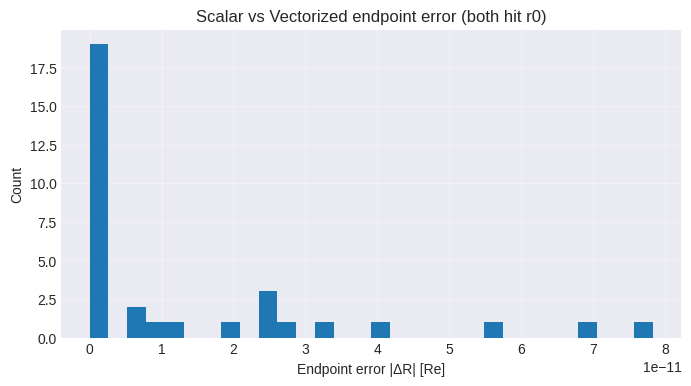

In [8]:
# Treat scalar status=0 as r0 reached (if scalar returns -1 etc., estimate from radius)
r_end_s = _norm3(df_scalar["xf"].values, df_scalar["yf"].values, df_scalar["zf"].values)
hit_r0_s = np.isfinite(r_end_s) & (np.abs(r_end_s - R0) <= R0_TOL)
hit_r0_v = (st_v == 0)

mask_ok = hit_r0_s & hit_r0_v

dx = xf_v - df_scalar["xf"].values
dy = yf_v - df_scalar["yf"].values
dz = zf_v - df_scalar["zf"].values
dr = np.sqrt(dx*dx + dy*dy + dz*dz)

df_cmp = pd.DataFrame({
    "i": np.arange(N_STARTS),
    "xi": xi, "yi": yi, "zi": zi,
    "scalar_status": df_scalar["status"].values,
    "vec_status": st_v,
    "scalar_r_end": r_end_s,
    "vec_r_end": _norm3(xf_v, yf_v, zf_v),
    "dxf": dx, "dyf": dy, "dzf": dz,
    "dR_endpoint": dr,
    "scalar_npts": df_scalar["npts"].values,
})
if nsteps_v is not None:
    df_cmp["vec_nsteps"] = nsteps_v

print("Endpoints compared (hit r0 on both):", int(np.sum(mask_ok)), "/", N_STARTS)
display(df_cmp.head())

# summary
if np.any(mask_ok):
    sub = df_cmp.loc[mask_ok, "dR_endpoint"].values
    print("\n[Endpoint error summary | both hit r0]")
    print("  mean:", float(np.mean(sub)))
    print("  p95 :", float(np.percentile(sub, 95)))
    print("  max :", float(np.max(sub)))

    plt.figure(figsize=(8,4))
    plt.hist(sub, bins=30)
    plt.xlabel("Endpoint error |ΔR| [Re]")
    plt.ylabel("Count")
    plt.title("Scalar vs Vectorized endpoint error (both hit r0)")
    plt.grid(True, alpha=0.3)
    plt.show()


## 8) Path agreement (resampled RMS)


Since path length differs per trace,

- Normalize to 0..1 by arc length

- Resample to RESAMPLE_N points

then compare (RMS and max).


Note: Only traces where both reached r0 are evaluated.

Path compared: 33


,i,rms,max,scalar_len,vec_len
0,2,5.102533e-10,7.660198e-10,23,23
1,4,2.651050e-10,3.824969e-10,31,31
2,8,8.541078e-14,1.594690e-13,41,41
3,11,2.267221e-10,3.786181e-10,25,25
4,13,2.541457e-15,3.877842e-15,17,17



[Path error summary]
  RMS mean: 7.390129450310249e-11
  RMS p95 : 3.7665435873250683e-10
  RMS max : 5.10253326001353e-10
  MAX mean: 1.1071131211922603e-10
  MAX p95 : 5.439926744772473e-10
  MAX max : 7.660198181941882e-10


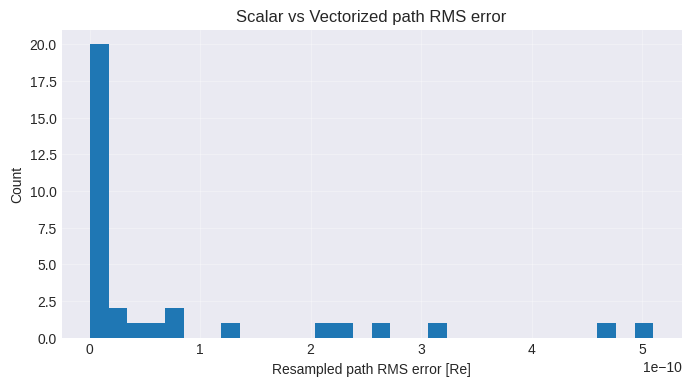

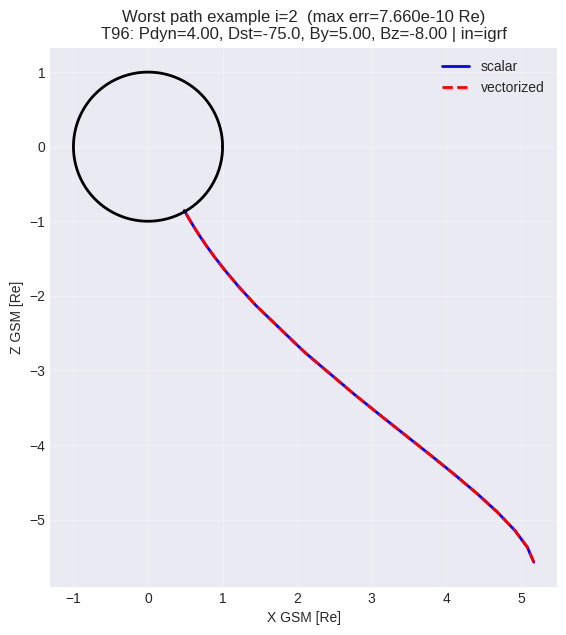

In [9]:
def rms_path_error(xa, ya, za, xb, yb, zb):
    d = np.sqrt((xa-xb)**2 + (ya-yb)**2 + (za-zb)**2)
    return float(np.sqrt(np.nanmean(d*d))), float(np.nanmax(d))

path_rows = []
worst = (-1, -np.inf)

for i in range(N_STARTS):
    if not mask_ok[i]:
        continue

    # scalar path
    try:
        xf, yf, zf, xs, ys, zs, st = scalar_trace_one(xi[i], yi[i], zi[i], DIR)
    except Exception:
        continue

    # vector path
    xv, yv, zv = masked_path_to_xyz(xx_v, yy_v, zz_v, i)

    # resample
    xs2, ys2, zs2 = resample_path(xs, ys, zs, RESAMPLE_N)
    xv2, yv2, zv2 = resample_path(xv, yv, zv, RESAMPLE_N)

    rms, mx = rms_path_error(xs2, ys2, zs2, xv2, yv2, zv2)
    path_rows.append(dict(i=i, rms=rms, max=mx, scalar_len=len(xs), vec_len=len(xv)))

    if mx > worst[1]:
        worst = (i, mx)

df_path = pd.DataFrame(path_rows)
print("Path compared:", len(df_path))
display(df_path.head())

if len(df_path) > 0:
    print("\n[Path error summary]")
    print("  RMS mean:", float(df_path["rms"].mean()))
    print("  RMS p95 :", float(np.percentile(df_path["rms"], 95)))
    print("  RMS max :", float(df_path["rms"].max()))
    print("  MAX mean:", float(df_path["max"].mean()))
    print("  MAX p95 :", float(np.percentile(df_path["max"], 95)))
    print("  MAX max :", float(df_path["max"].max()))

    plt.figure(figsize=(8,4))
    plt.hist(df_path["rms"], bins=30)
    plt.xlabel("Resampled path RMS error [Re]")
    plt.ylabel("Count")
    plt.title("Scalar vs Vectorized path RMS error")
    plt.grid(True, alpha=0.3)
    plt.show()

    # worst example plot
    i_worst = worst[0]
    if i_worst >= 0:
        _, _, _, xs, ys, zs, _ = scalar_trace_one(xi[i_worst], yi[i_worst], zi[i_worst], DIR)
        xv, yv, zv = masked_path_to_xyz(xx_v, yy_v, zz_v, i_worst)
        plot_xz_lines(
            [
                {"x": xs, "z": zs, "style": "b-", "label": "scalar"},
                {"x": xv, "z": zv, "style": "r--", "label": "vectorized"},
            ],
            title=f"Worst path example i={i_worst}  (max err={worst[1]:.3e} Re)\n{pretty_parmod(EXNAME, PARMOD)} | in={INNAME}"
        )


## 9) Tangency check: angle(tangent, B)


The closer the path tangent t and B match, the better (ideal is 0 deg).

Here we compute θ = arccos(|t·B̂|) at each point and report statistics.


Note:

- B is evaluated using the same model (internal+external) that trace uses

- Setting STRICT_SCALAR_MODELS to True makes B evaluation scalar-based (slow but prioritizes consistency)

Tangency evaluated: 33


,i,ang_mean,ang_p95,ang_max,n_eval
0,2,0.276627,0.638428,1.502440,21
1,4,0.230293,0.853534,2.202899,29
2,8,0.534951,1.902883,2.147352,39
3,11,0.257240,0.648582,1.700597,23
4,13,0.581630,2.502035,2.506447,15



[Tangency angle summary | vector path]
  mean(ang_mean): 0.3706952722636803 deg
  p95 (ang_p95) : 2.7868788525450516 deg
  max (ang_max) : 5.913523532913301 deg


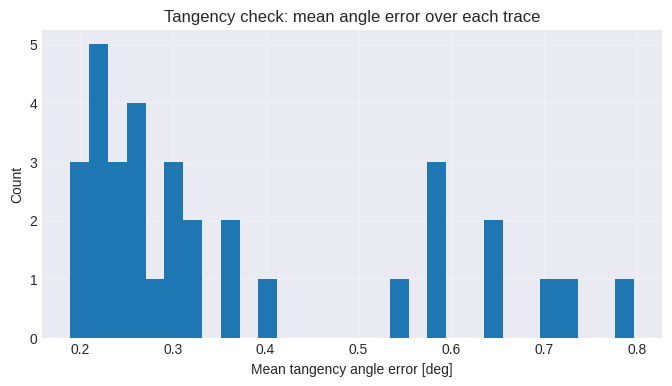

In [10]:
ang_rows = []
for i in range(N_STARTS):
    if not mask_ok[i]:
        continue

    # vectorized path (evaluate on vector side since there are many points)
    xv, yv, zv = masked_path_to_xyz(xx_v, yy_v, zz_v, i)
    ang = tangent_angle_error_deg(
        xv, yv, zv,
        EXNAME, INNAME, PARMOD, ps,
        strict_scalar=STRICT_SCALAR_MODELS
    )
    if ang.size == 0:
        continue
    ang_rows.append(dict(
        i=i,
        ang_mean=float(np.nanmean(ang)),
        ang_p95=float(np.nanpercentile(ang, 95)),
        ang_max=float(np.nanmax(ang)),
        n_eval=int(np.sum(np.isfinite(ang))),
    ))

df_ang = pd.DataFrame(ang_rows)
print("Tangency evaluated:", len(df_ang))
display(df_ang.head())

if len(df_ang) > 0:
    print("\n[Tangency angle summary | vector path]")
    print("  mean(ang_mean):", float(df_ang["ang_mean"].mean()), "deg")
    print("  p95 (ang_p95) :", float(np.percentile(df_ang["ang_p95"], 95)), "deg")
    print("  max (ang_max) :", float(df_ang["ang_max"].max()), "deg")

    plt.figure(figsize=(8,4))
    plt.hist(df_ang["ang_mean"], bins=30)
    plt.xlabel("Mean tangency angle error [deg]")
    plt.ylabel("Count")
    plt.title("Tangency check: mean angle error over each trace")
    plt.grid(True, alpha=0.3)
    plt.show()
